In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [ ]:
df = pd.read_csv("Insurance_Annual_Premium/medical_insurance.csv")

In [3]:
print(f'df.head() = \n{df.head()}')
print(f'\ndf.shape = \n{df.shape}')
print(f'\ndf.columns = \n{df.columns.tolist()}')
print(f"\ndf.info() = ")
df.info()

df.head() = 
   person_id  age     sex   region urban_rural   income     education  \
0      75722   52  Female    North    Suburban  22700.0     Doctorate   
1      80185   79  Female    North       Urban  12800.0         No HS   
2      19865   68    Male    North       Rural  40700.0            HS   
3      76700   15    Male    North    Suburban  15600.0  Some College   
4      92992   53    Male  Central    Suburban  89600.0     Doctorate   

  marital_status employment_status  household_size  ...  liver_disease  \
0        Married           Retired               3  ...              0   
1        Married          Employed               3  ...              0   
2        Married           Retired               5  ...              0   
3        Married     Self-employed               5  ...              0   
4        Married     Self-employed               2  ...              0   

   arthritis mental_health proc_imaging_count  proc_surgery_count  \
0          1             0        

In [4]:
cols_to_keep = ['smoker', 'age', 'bmi', 'region', 'dependents', 'sex', 'annual_premium']#, 'risk_score', 'chronic_count', 'is_high_risk', 'days_hospitalized_last_3yrs', 'hospitalizations_last_3yrs', 'annual_premium']
df = df[cols_to_keep]
# mask = df['age']>=18
# df = df[mask]

In [5]:
print(df.isnull().sum())
df = df.dropna()
print(df.isnull().sum())

smoker            0
age               0
bmi               0
region            0
dependents        0
sex               0
annual_premium    0
dtype: int64
smoker            0
age               0
bmi               0
region            0
dependents        0
sex               0
annual_premium    0
dtype: int64


In [6]:
print(df['sex'].unique().tolist())
print(df['region'].unique().tolist())
# print(df['urban_rural'].unique().tolist())
# print(df['education'].unique().tolist())
# print(df['marital_status'].unique().tolist())
# print(df['employment_status'].unique().tolist())
print(df['smoker'].unique().tolist())
# print(df['alcohol_freq'].unique().tolist())
# print(df['plan_type'].unique().tolist())
# print(df['network_tier'].unique().tolist())
# print(df['hypertension'].unique().tolist())
# print(df['diabetes'].unique().tolist())
# print(df['asthma'].unique().tolist())
# print(df['copd'].unique().tolist())
# print(df['cardiovascular_disease'].unique().tolist())
# print(df['cancer_history'].unique().tolist())
# print(df['kidney_disease'].unique().tolist())
# print(df['liver_disease'].unique().tolist())
# print(df['arthritis'].unique().tolist())
# print(df['mental_health'].unique().tolist())
# print(df['is_high_risk'].unique().tolist())
# print(df['had_major_procedure'].unique().tolist())

['Female', 'Male', 'Other']
['North', 'Central', 'West', 'South', 'East']
['Never', 'Current', 'Former']


In [ ]:
df.insert(loc=0, column='intercept', value=1)

df_encoded = pd.get_dummies(df, dtype=int, drop_first=True)

cols_to_drop = ['annual_premium', 'monthly_premium', 'annual_medical_cost', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'person_id']

new_columns = [col for col in df_encoded.columns if (col not in cols_to_drop)] + ['annual_premium']
df_encoded = df_encoded[new_columns]

print(f'df.head() = \n{df.head()}')
print()
print(f'df_encoded.head() = \n{df_encoded.head()}')

df_encoded.to_csv("Insurance_Annual_Premium/cleaned_insurance_with_intercept.csv", index=False)
print("Successfully generated cleaned_insurance_with_intercept.csv")

df_order_2 = pd.get_dummies(df, dtype=int, drop_first=False)

print(f'\ndf_order_2.columns = \n{df_order_2.columns.tolist()}')

# cols = ['age', 'sex_Female', 'sex_Male', 'sex_Other', 'region_Central', 'region_East', 'region_North', 'region_South', 'region_West', 'urban_rural_Rural', 'urban_rural_Suburban', 'urban_rural_Urban', 'income', 'education_Bachelors', 'education_Doctorate', 'education_HS', 'education_Masters', 'education_No HS', 'education_Some College', 'marital_status_Divorced', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed', 'employment_status_Employed', 'employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Unemployed', 'household_size', 'dependents', 'bmi', 'smoker_Current', 'smoker_Former', 'smoker_Never', 'alcohol_freq_Daily', 'alcohol_freq_Occasional', 'alcohol_freq_Weekly', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type_EPO', 'plan_type_HMO', 'plan_type_POS', 'plan_type_PPO', 'network_tier_Bronze', 'network_tier_Gold', 'network_tier_Platinum', 'network_tier_Silver', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']
cols = ['smoker_Current', 'smoker_Former', 'smoker_Never', 'age', 'bmi', 'region_Central', 'region_East', 'region_North', 'region_South', 'region_West', 'dependents', 'sex_Female', 'sex_Male', 'sex_Other']#, 'risk_score', 'chronic_count', 'is_high_risk', 'days_hospitalized_last_3yrs', 'hospitalizations_last_3yrs']
sex = ['sex_Female', 'sex_Male', 'sex_Other']
region = ['region_Central', 'region_East', 'region_North', 'region_South', 'region_West']
urban_rural = ['urban_rural_Rural', 'urban_rural_Suburban', 'urban_rural_Urban']
education = ['education_Bachelors', 'education_Doctorate', 'education_HS', 'education_Masters', 'education_No HS', 'education_Some College']
marital_status = ['marital_status_Divorced', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed']
employment_status = ['employment_status_Employed', 'employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Unemployed']
smoker = ['smoker_Current', 'smoker_Former', 'smoker_Never']
alcohol_freq = ['alcohol_freq_Daily', 'alcohol_freq_Occasional', 'alcohol_freq_Weekly']
plan_type = ['plan_type_EPO', 'plan_type_HMO', 'plan_type_POS', 'plan_type_PPO']
network_tier = ['network_tier_Bronze', 'network_tier_Gold', 'network_tier_Platinum', 'network_tier_Silver']
# hypertension = [0, 1]
# diabetes = [0, 1]
# asthma = [0, 1]
# copd = [0, 1]
# cardiovascular_disease = [0, 1]
# cancer_history = [0, 1]
# kidney_disease = [0, 1]
# liver_disease = [0, 1]
# arthritis = [0, 1]
# mental_health = [0, 1]
# is_high_risk = [0, 1]
# had_major_procedure = [0, 1]

interactions = {}

for i in range(len(cols)-1):
    for j in range(i,len(cols)):
        if cols[i] in sex and cols[j] in sex:
            continue
        elif cols[i] in region and cols[j] in region:
            continue
        elif cols[i] in urban_rural and cols[j] in urban_rural:
            continue
        elif cols[i] in education and cols[j] in education:
            continue
        elif cols[i] in marital_status and cols[j] in marital_status:
            continue
        elif cols[i] in employment_status and cols[j] in employment_status:
            continue
        elif cols[i] in smoker and cols[j] in smoker:
            continue
        elif cols[i] in alcohol_freq and cols[j] in alcohol_freq:
            continue
        elif cols[i] in plan_type and cols[j] in plan_type:
            continue
        elif cols[i] in network_tier and cols[j] in network_tier:
            continue
        else:
            new_col = cols[i] + ' x ' + cols[j]
            interactions[new_col] = df_order_2[cols[i]] * df_order_2[cols[j]]

df_interactions = pd.DataFrame(interactions, index=df_order_2.index)
df_order_2 = pd.concat([df_order_2, df_interactions], axis=1)

new_order_2_columns = [col for col in df_order_2.columns if (col not in cols_to_drop)] + ['annual_premium']
df_order_2 = df_order_2[new_order_2_columns]

df_order_2.to_csv("Insurance_Annual_Premium/cleaned_order_2_insurance_with_intercept.csv", index=False)
print("Successfully generated cleaned_order_2_insurance_with_intercept.csv")

df.head() = 
   intercept smoker  age   bmi   region  dependents     sex  annual_premium
0          1  Never   52  27.4    North           1  Female          876.05
1          1  Never   79  26.6    North           1  Female          445.10
2          1  Never   68  31.5    North           3    Male         1538.02
3          1  Never   15  31.6    North           3    Male          820.63
4          1  Never   53  30.5  Central           0    Male          500.93

df_encoded.head() = 
   intercept  age   bmi  dependents  smoker_Former  smoker_Never  region_East  \
0          1   52  27.4           1              0             1            0   
1          1   79  26.6           1              0             1            0   
2          1   68  31.5           3              0             1            0   
3          1   15  31.6           3              0             1            0   
4          1   53  30.5           0              0             1            0   

   region_North  regio

In [8]:
print(f'\ndf_encoded.columns = \n{df_encoded.columns.tolist()}')


df_encoded.columns = 
['intercept', 'age', 'bmi', 'dependents', 'smoker_Former', 'smoker_Never', 'region_East', 'region_North', 'region_South', 'region_West', 'sex_Male', 'sex_Other', 'annual_premium']


In [9]:
min(df_encoded['age']), max(df_encoded['age'])

(0, 100)

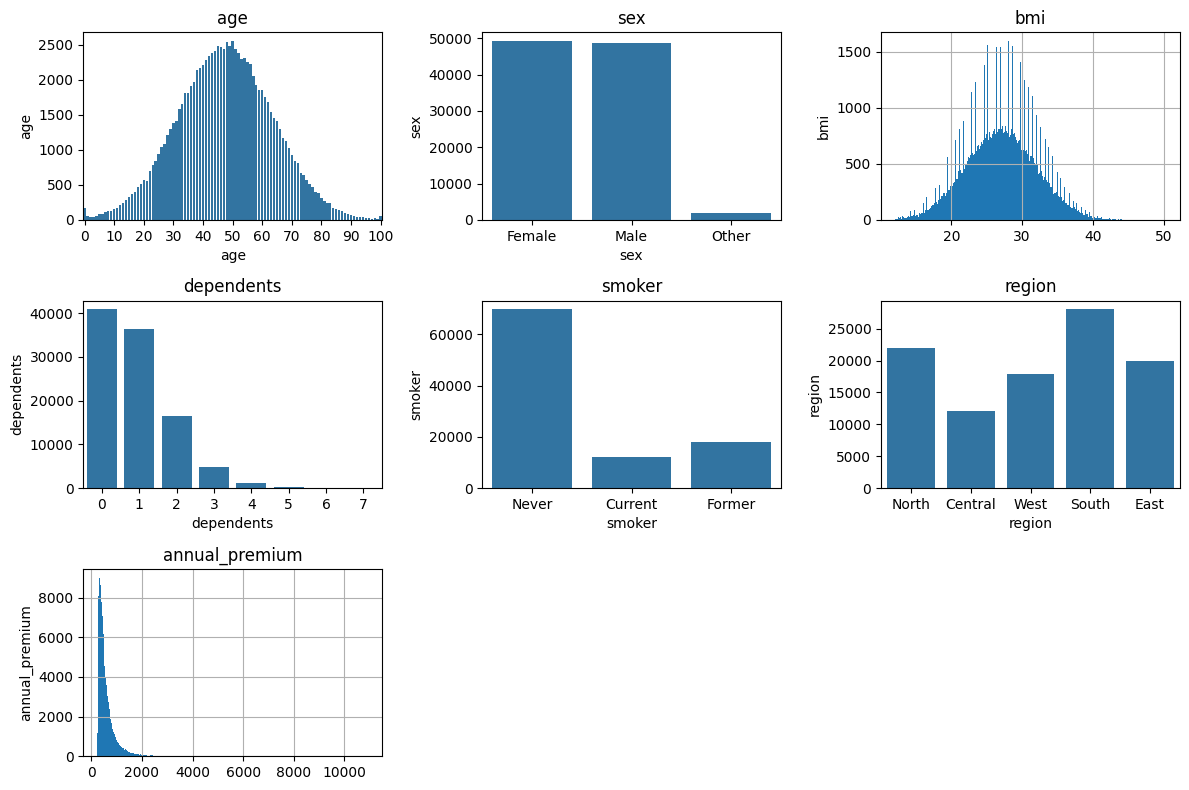

In [ ]:
plt.figure(figsize=(12,8))
for i, col in enumerate(['age', 'sex', 'bmi', 'dependents', 'smoker', 'region', 'annual_premium']):
    plt.subplot(3,3,i+1)
    if col in ['sex', 'smoker', 'region', 'dependents']:
        sns.countplot(x=col, data=df)
    elif col == 'age':
        sns.countplot(x='age', data=df)
        plt.xticks(np.arange(0, 101, step=10))
    else:
        df[col].hist(bins=317)
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('Insurance_Annual_Premium/histograms.png',dpi=400,bbox_inches='tight')
plt.show()

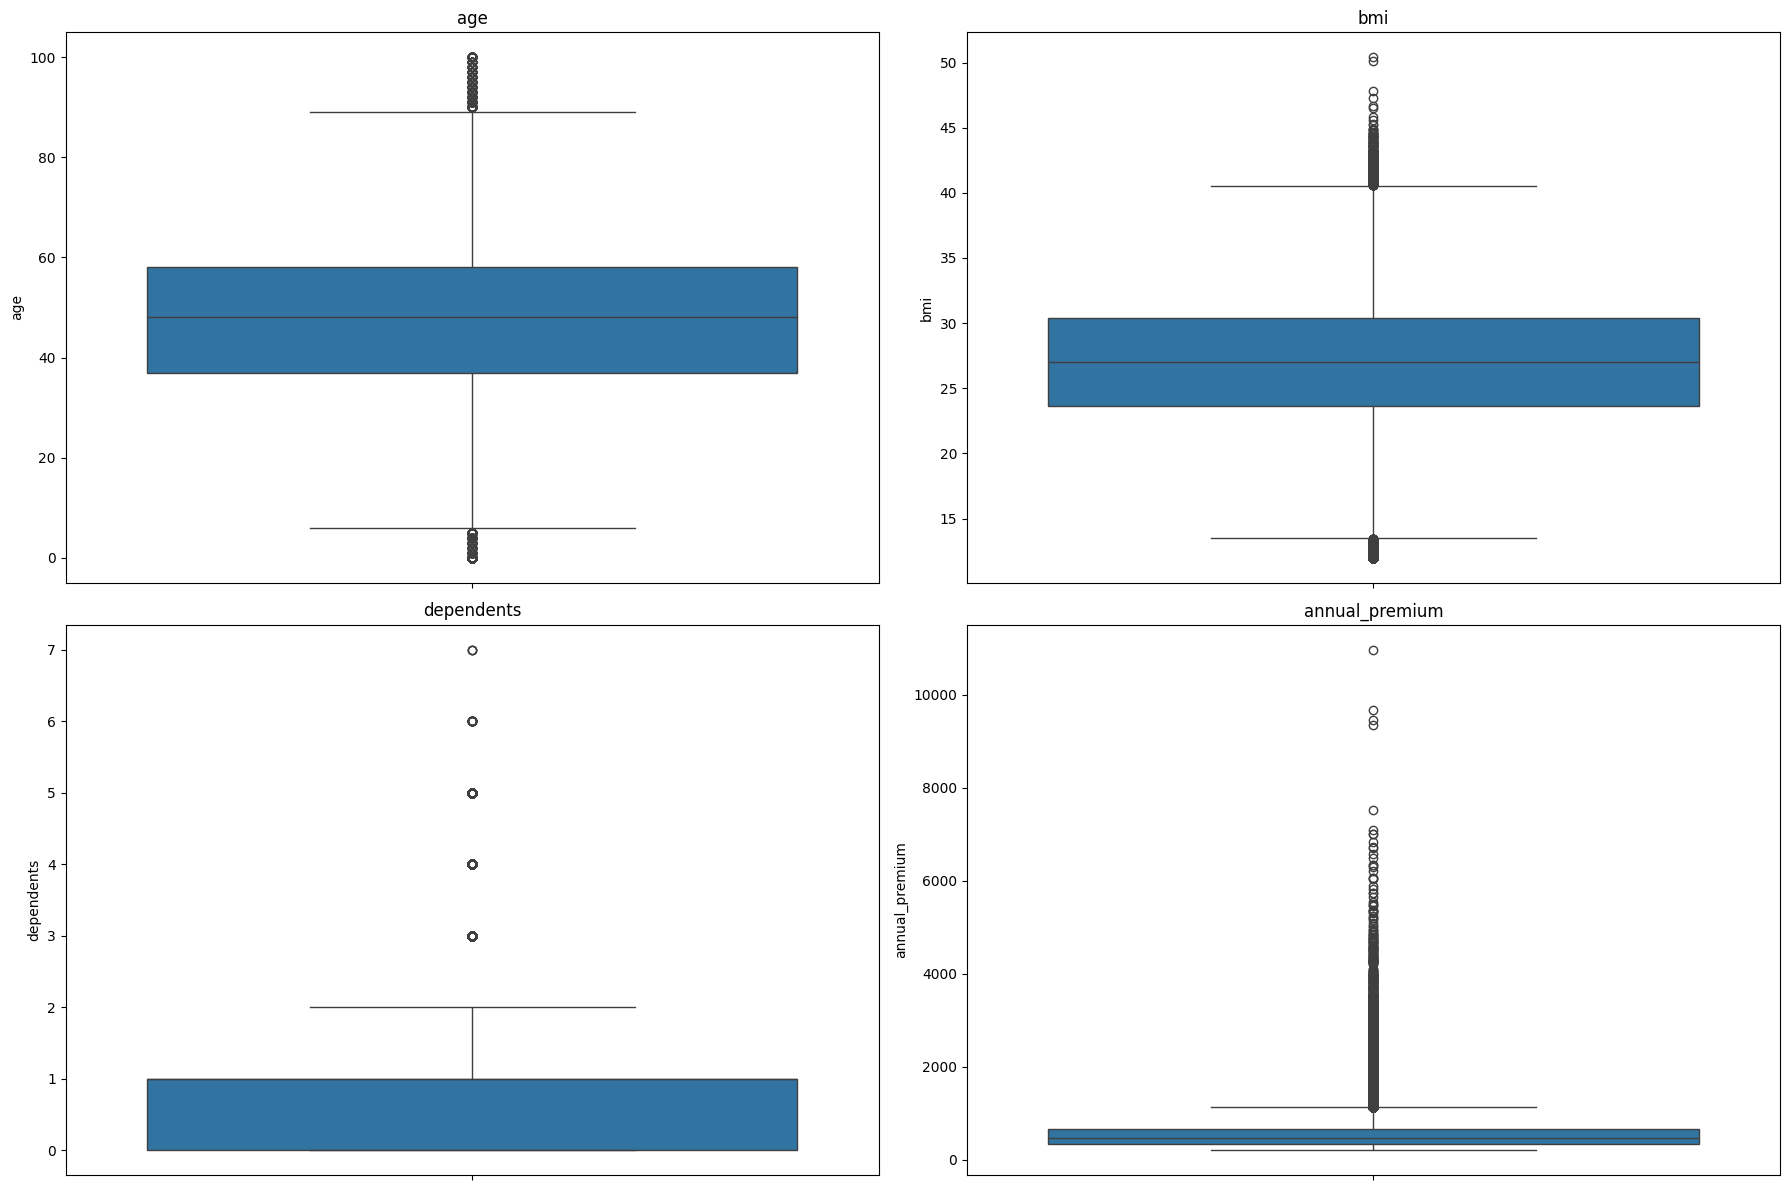

In [ ]:
plt.figure(figsize=(18,12))
for i, col in enumerate(['age', 'bmi', 'dependents', 'annual_premium']):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('Insurance_Annual_Premium/boxplots.png',dpi=400,bbox_inches='tight')
plt.show()

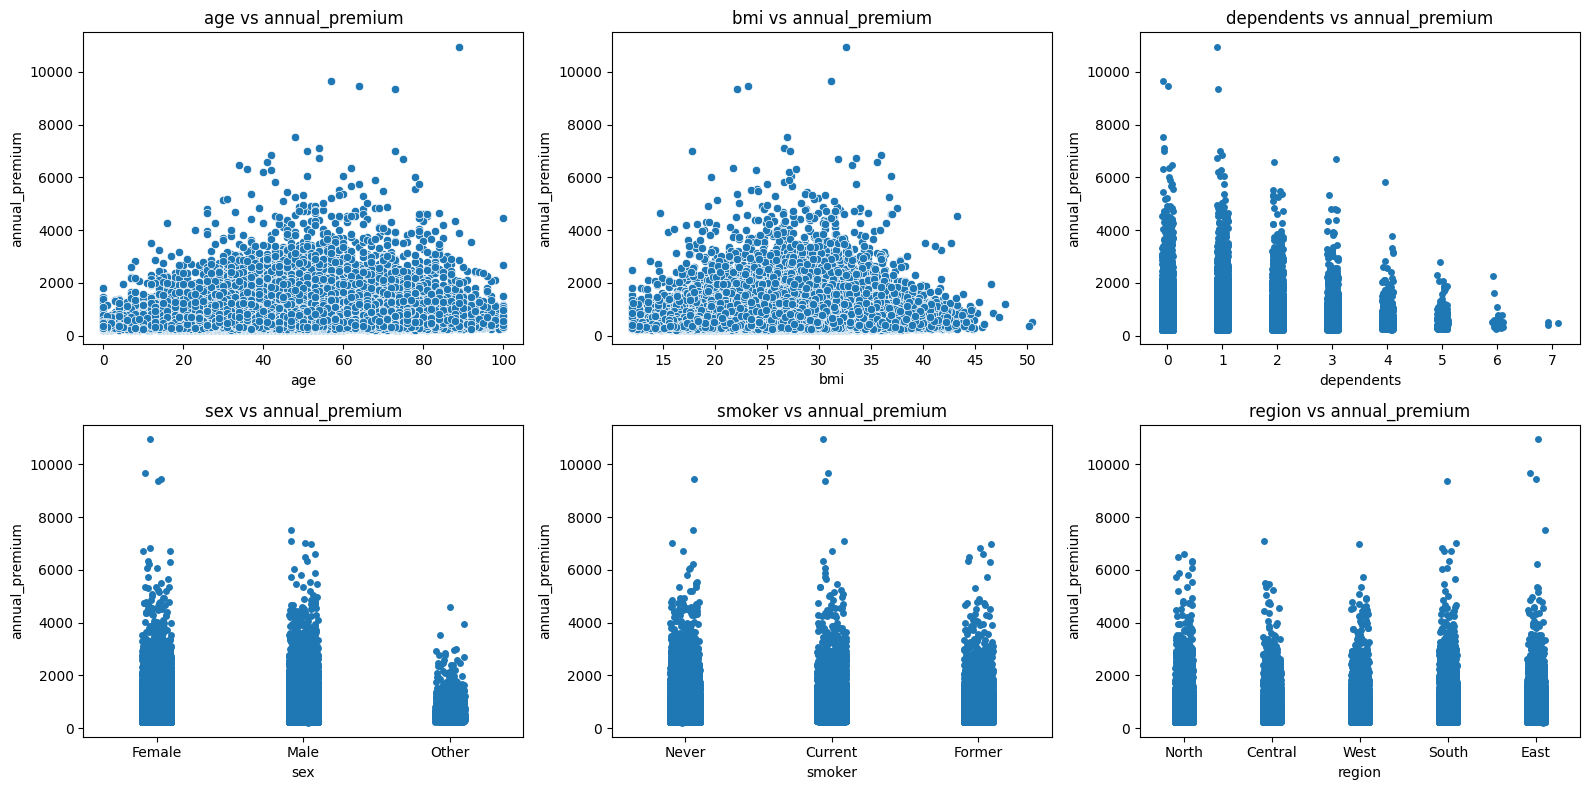

In [ ]:
df['dependents'] = df['dependents'].astype('category')
features = ['age', 'bmi', 'dependents', 'sex', 'smoker', 'region']
cats = ['dependents', 'sex', 'smoker', 'region']

plt.figure(figsize=(16,8))

for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    if col not in cats:
        sns.scatterplot(x=df[col], y=df['annual_premium'])
    else:
        sns.stripplot(x=df[col], y=df['annual_premium'])
    plt.title(f"{col} vs annual_premium")

plt.tight_layout()
plt.savefig('Insurance_Annual_Premium/scatterplots.png',dpi=400,bbox_inches='tight')
plt.show()

In [13]:
# Replace 'target_column' with your actual column name
target_corr = df_encoded.drop('intercept', axis=1).corr(numeric_only=True)['annual_premium'].abs().sort_values(ascending=False)

# Exclude the first result (the column's correlation with itself, which is 1.0)
print(target_corr[1:].head(20))

age              0.127473
smoker_Never     0.123976
bmi              0.041675
smoker_Former    0.022407
region_South     0.006187
region_East      0.004595
dependents       0.003947
sex_Male         0.003549
sex_Other        0.001247
region_West      0.000782
region_North     0.000245
Name: annual_premium, dtype: float64


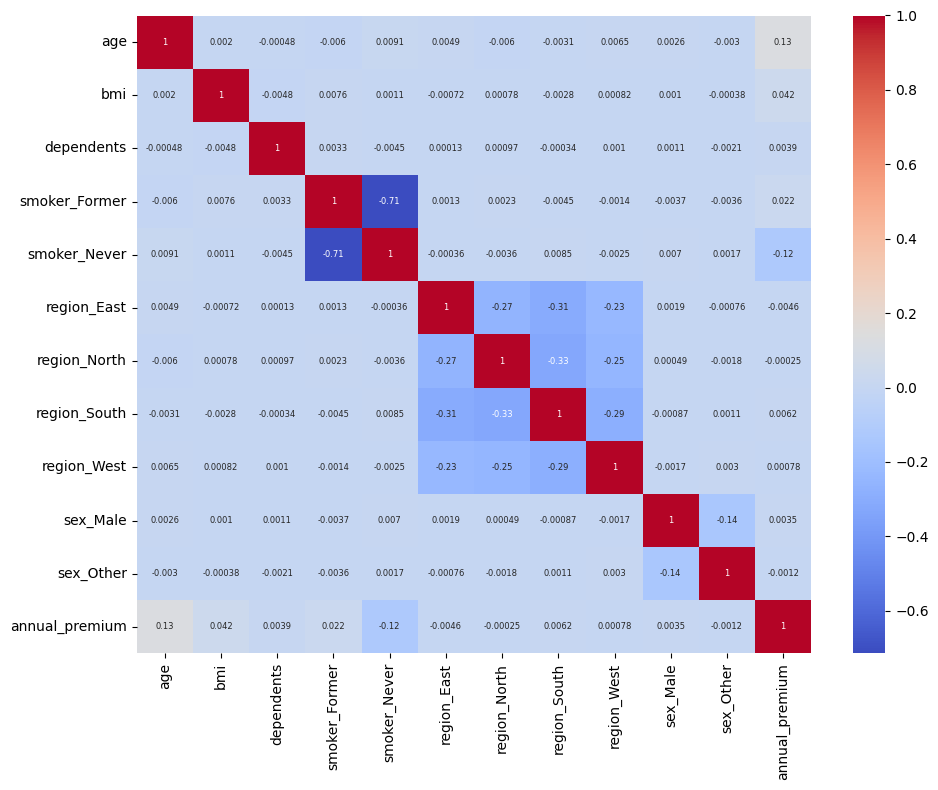

In [ ]:
corr = df_encoded.drop('intercept', axis=1).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr , annot = True , cmap = 'coolwarm', annot_kws={"size": 6})
# ax.tick_params(axis='both', which='major', labelsize=1)

plt.tight_layout()
plt.savefig('Insurance_Annual_Premium/correlation_heatmap.png',dpi = 300,bbox_inches='tight')
plt.show()

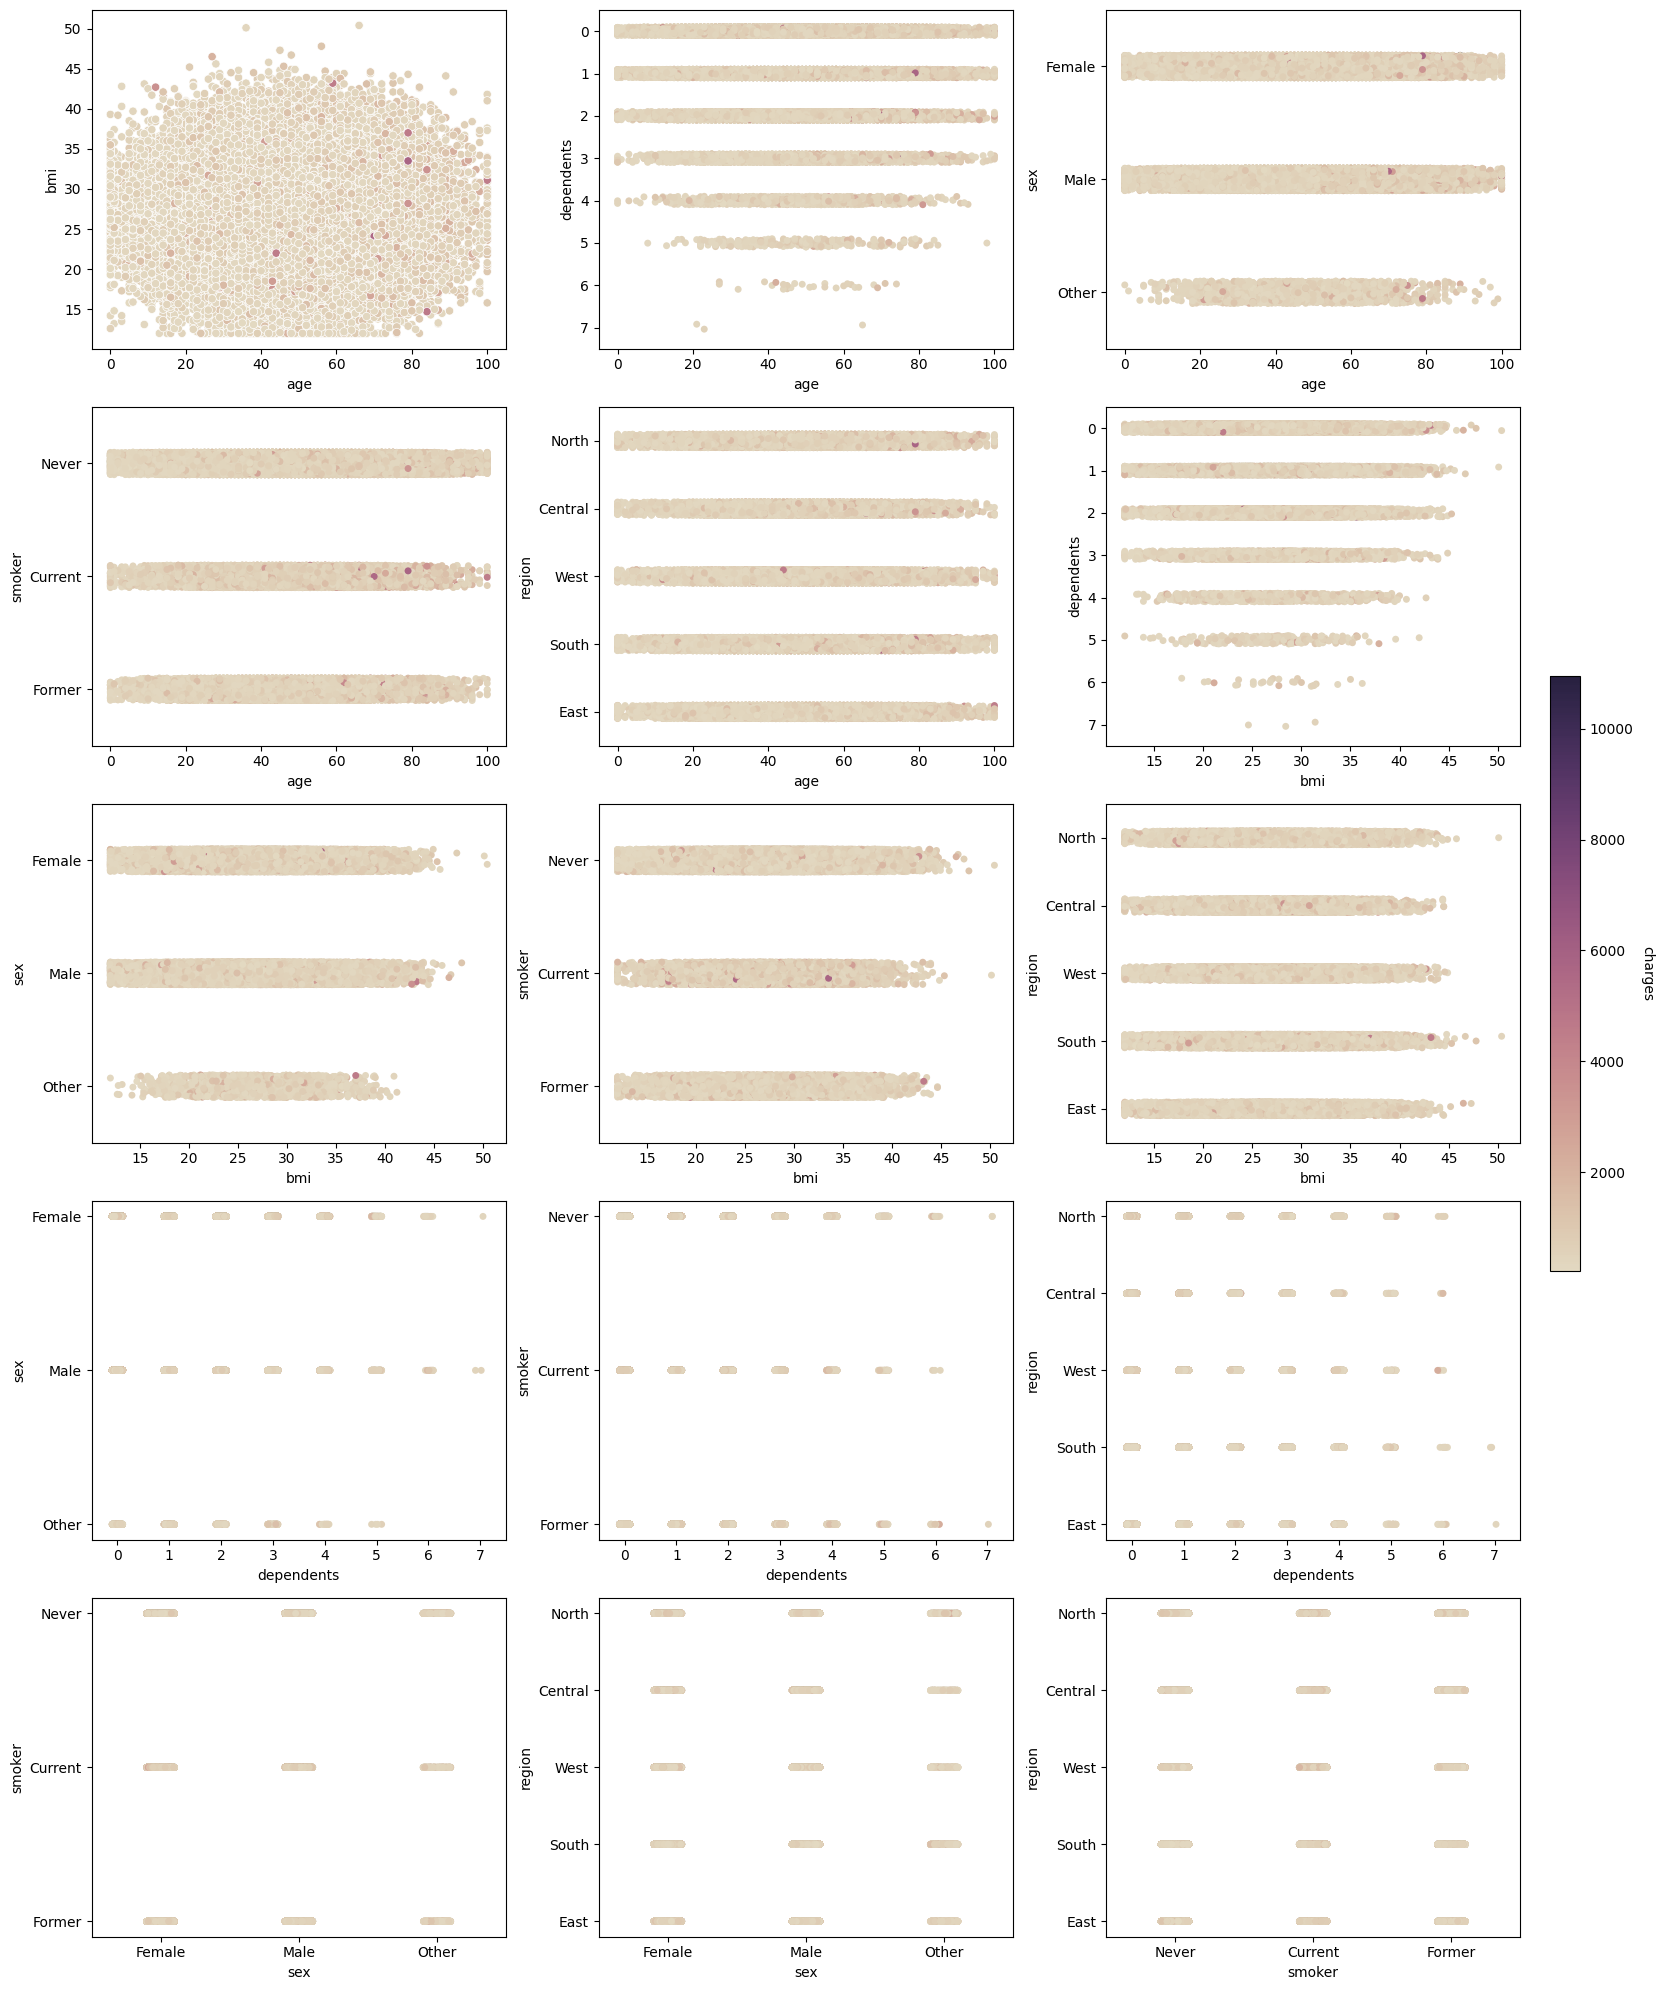

In [ ]:
my_norm = colors.Normalize(vmin=df['annual_premium'].min(), vmax=df['annual_premium'].max())
# sns.cubehelix_palette(as_cmap=True)
my_cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)

n = 1
fig = plt.figure(figsize=(16, 20))

for i in range(len(features)-1):
    for j in range(i+1, len(features)):
        plt.subplot(5, 3, n)
        
        if (features[i] not in cats) and (features[j] not in cats):
            sns.scatterplot(x=features[i], y=features[j], hue='annual_premium', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        else:
            sns.stripplot(x=features[i], y=features[j], hue='annual_premium', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        n = n + 1

plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=my_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.02)
cbar.set_label('charges', rotation=270, labelpad=15)

plt.savefig('Insurance_Annual_Premium/Hue_Plots.png',dpi=400,bbox_inches='tight')
plt.show()

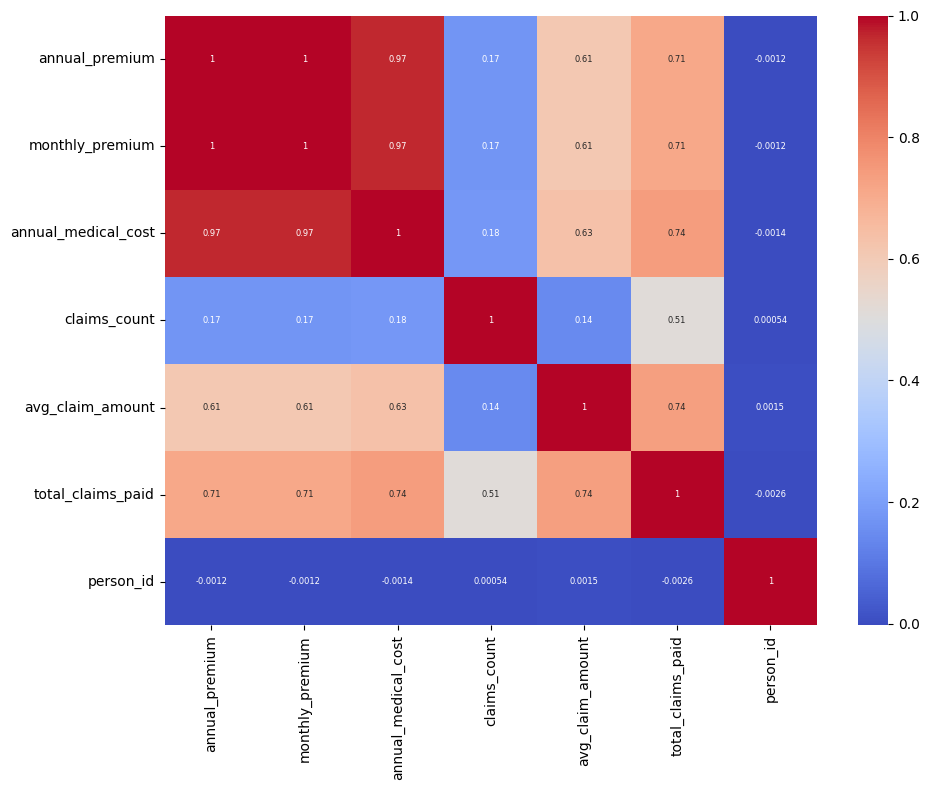

In [ ]:
df = pd.read_csv("Insurance_Annual_Premium/medical_insurance.csv")
cols_to_drop = ['annual_premium', 'monthly_premium', 'annual_medical_cost', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'person_id']
df = df[cols_to_drop]

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr , annot = True , cmap = 'coolwarm', annot_kws={"size": 6})
# ax.tick_params(axis='both', which='major', labelsize=1)

plt.tight_layout()

plt.show()